Visualize what best fit parameters mean

In [12]:
import zeus21
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import importlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from astropy import units as u
from scipy.integrate import trapezoid as trapz
import dataframe_image as dfi
from matplotlib.gridspec import GridSpec
import math
import matplotlib.ticker as ticker
import corner

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Chemerynska+25.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'Chemerynska+25', 'wrong dz']
sorted_data = edata.get_sorted(file_names, data_labels)

In [11]:
params = eMCMC.build_param_data({'beta': {'fit':False, 'value': -0.54}, 'dbetadz': {'fit': False, 'value':0}})

In [4]:
best_fit = [0.87, 0.05, 11.71, 0, -0.98, -0.05, 0.17, 0.17, -0.86]
other_fit = [.6, -0.03, 12, 0.08, -0.98, -0.05, 0.17, 0.3, 0]

In [5]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:196: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:196: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-',
/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/

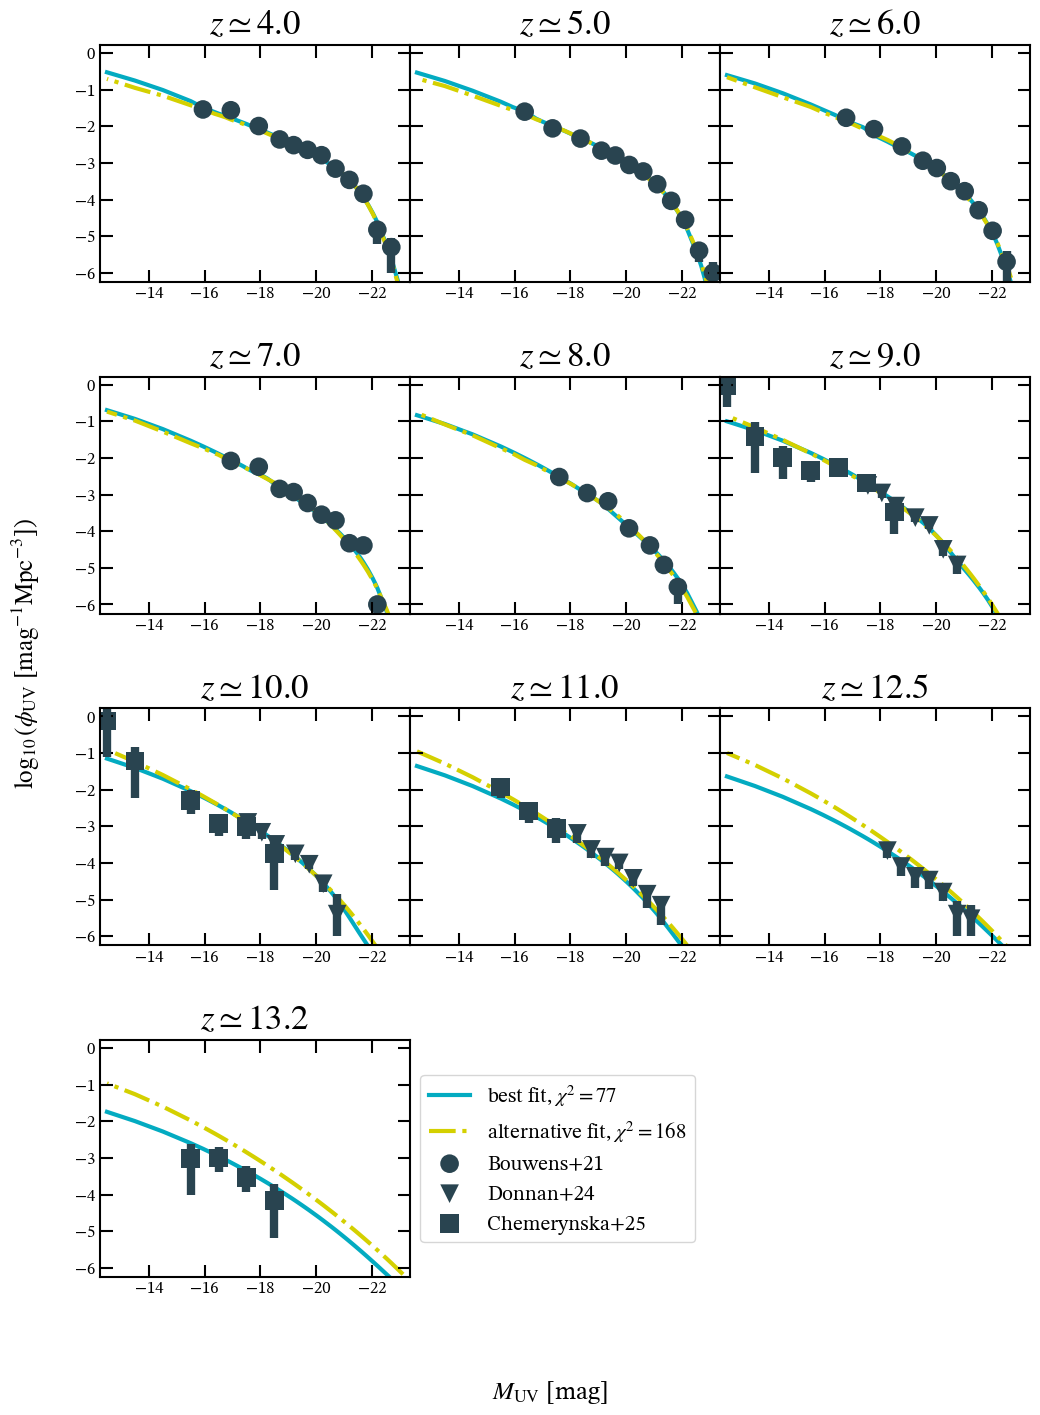

In [6]:
comparison_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [best_fit, other_fit], 
                               comparison_labels = [r'best fit', 'alternative fit'], title = '')

In [7]:
comparison_fig.savefig('/Users/eb35267/Desktop/code/home/figures/GLIMPSE_comparison.png', bbox_inches='tight')

In [11]:
param_labels = my_UVLF.param_data['label'].values[my_UVLF.param_data['fit'].values.astype(bool)]
table_comparison = eplots.make_table([best_fit, other_fit], param_labels, 
                                     fit_labels = ['best fit', 'alternative fit'],  
                                     bounds = [None, None])

In [ ]:
#dfi.export(table_comparison, '/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/fit_comparison_table.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

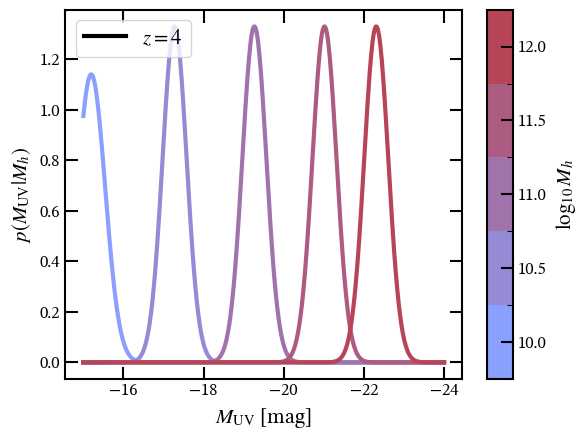

In [12]:
Mhtab = np.arange(10, 12.5, 0.5)
fig = eplots.MUV_distribution(my_UVLF, [4], best_fit, Mhtab)

In [ ]:
#fig.savefig('/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/pMUVMh_bf.png', bbox_inches='tight')

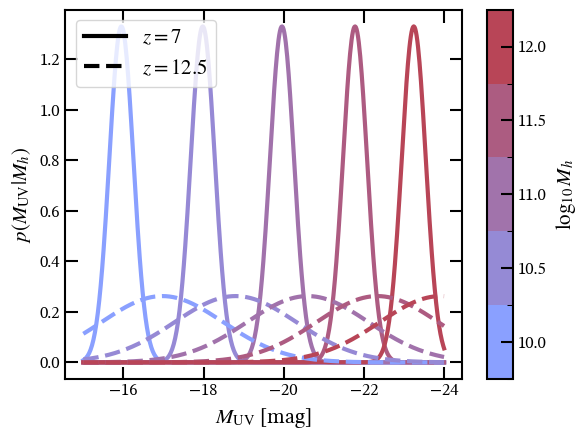

In [13]:
fig = eplots.MUV_distribution(my_UVLF, [7, 12.5], other_fit, Mhtab)

In [ ]:
# fig.savefig('/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/pMUVMh_af.png', bbox_inches='tight')

In [43]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/all_data_test/pMUV_Mh.png', bbox_inches='tight')

# SFE($M_h$) for different $z$

In [16]:
def plot_sfe_evolution(my_UVLF, param_values, Mhtab, zmax, steps = 100):
    
    fig, ax = plt.subplots()
    zs = np.linspace(0, zmax, steps)

    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.periwinkle, eplots.red], Mhtab)

    for Mh in Mhtab:
        SFEs = np.zeros(steps)
        Mz = calc_Mz(zs, Mh, my_UVLF)
        for i, (z, Mz_i) in enumerate(zip(zs, Mz)):
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)
                           
            SFEs[i] = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
                Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mz_i)
        
        frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
        color = cmap(frac)
        ax.plot(zs, SFEs, color = color, ls = '-')

    # Color bar things:
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$ at $z=0$')

    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
    ax.set_xlabel('redshift')
    ax.set_yscale('log')

    return fig

def calc_Mz(zs, M0, my_UVLF):
    steps = len(zs)
    Ms = np.zeros(steps+1)
    Ms[0] = 10**M0
    dz = (zs.max() - zs.min())/(steps+1)
    for i in range(steps):
        # Multiply dM/dt by dt/dz to get M_dot
        M_dot = calc_M_dot(Ms[i], zs[i], my_UVLF) /  ((1+zs[i]) * 
                                                      (zeus21.Hub(my_UVLF.CosmoParams, zs[i])*u.km/(u.s*u.Mpc)).to(u.year**-1).value) 
        # Had to take out a negative here to make it work; not sure why. Normally dt/dz would include a -(1+z)
        Ms[i+1] = Ms[i] - (M_dot * dz)

    return np.log10(Ms)

def calc_M_dot(M_h, z, my_UVLF):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((my_UVLF.CosmoParams.OmegaM*(1+z)**3)+my_UVLF.CosmoParams.OmegaL)

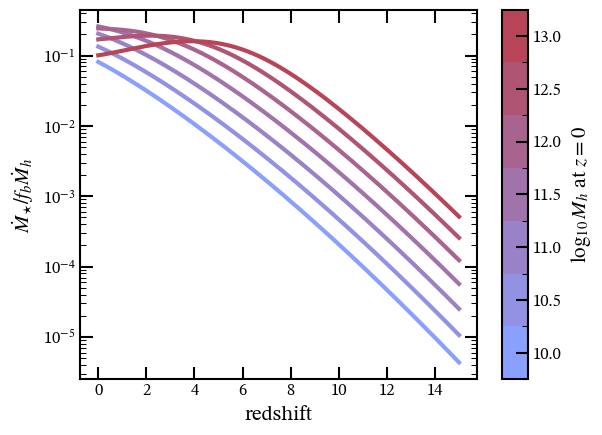

In [17]:
sfe_fig = plot_sfe_evolution(my_UVLF, best_fit, np.arange(10, 13.5, 0.5), 15, 200)

In [51]:
10**-0.8

0.15848931924611134

In [ ]:
#sfe_fig.savefig('/Users/eb35267/Desktop/code/figures/all_data_test/sfe_over_redshift.png', bbox_inches='tight')

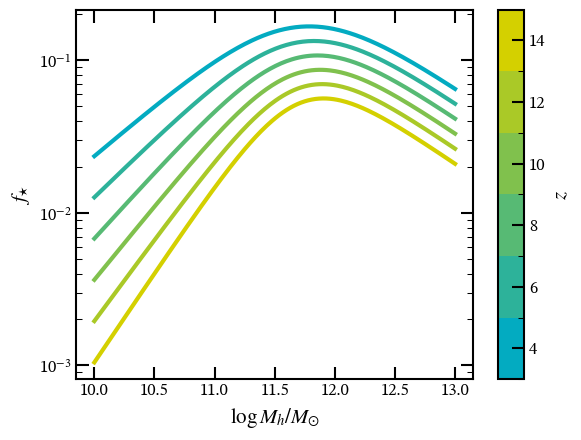

In [65]:
sfe_fig_2 = eplots.sfe_shape_diff_z(my_UVLF, best_fit, Mhtab = np.linspace(10, 13, 200), 
                             zs = np.arange(4, 16, 2))

In [59]:
sfe_fig_2.savefig('/Users/eb35267/Desktop/figures/Committee_25/sfe.png', bbox_inches='tight')

In [37]:
10**(my_UVLF.time_evolution(best_fit, 9)[3])

0.0933254300796991

In [39]:
my_UVLF.time_evolution(best_fit, 9)

[0.92, -0.54, 11.71, -1.03, array([1.2 , 0.77, 0.34, 0.3 , 0.3 ])]

In [ ]:
#sfe_fig_2.savefig('/Users/eb35267/Desktop/figures/Committee_25/sfe.png', bbox_inches='tight')

In [126]:
my_UVLF.data[0]

[4.0,
 0.5,
 array([-22.69, -22.19, -21.69, -21.19, -20.69, -20.19, -19.69, -19.19,
        -18.69, -17.94, -16.94, -15.94]),
 array([5.000e-06, 1.500e-05, 1.440e-04, 3.440e-04, 6.980e-04, 1.624e-03,
        2.276e-03, 3.056e-03, 4.371e-03, 1.016e-02, 2.742e-02, 2.882e-02]),
 array([4.00e-06, 9.00e-06, 2.20e-05, 3.80e-05, 6.80e-05, 1.31e-04,
        1.99e-04, 3.88e-04, 6.89e-04, 9.20e-04, 3.44e-03, 8.74e-03]),
 array([4.00e-06, 9.00e-06, 2.20e-05, 3.80e-05, 6.80e-05, 1.31e-04,
        1.99e-04, 3.88e-04, 6.89e-04, 9.20e-04, 3.44e-03, 8.74e-03]),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])]

# P(Mh|MUV)

In [ ]:
def PMh(param_values, my_UVLF, MUV_range, z_range):

    fig, ax = plt.subplots(len(z_range), 1, sharex = True) 
    if len(z_range) == 1:
        ax = [ax]
    fig.set_size_inches(6, 3*len(z_range))
    plt.subplots_adjust(hspace = 0)
    
    # Define colormap
    cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.orange, eplots.navy], MUV_range)

    # Define grid of halo masses
    Mhtab = np.logspace(8, 14, 200)
    my_UVLF.HMFintclass.Mhtab = Mhtab

    for i, z in enumerate(z_range):
        # Get the HMF at that redshift
        hmf = my_UVLF.HMFintclass.HMF_int(Mhtab, z)
        # Integtrate over the HMF
        hmf_integral = trapz(hmf, Mhtab)

        # Get the time-evolving parameters
        params = my_UVLF.time_evolution(param_values, z) # Calculate how parameters evolve with redshift
        astroparams = my_UVLF.param_wrapper(params)# Get the parameters in the right format for use with zeus21
        
        # Use the parameter values to get MUV_bar at a given Mh
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, Mhtab, z, z) # Calculate SFR
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV) # Use SFR to calculate average MUV
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX) # Make sure that MUV doesn't exceed a set value

        for MUV in MUV_range:
            probabilities = np.zeros_like(Mhtab)

            # Calculate probability for each pair of Mh, MUV
            for j, (sigUV, MUV_bar, Mh) in enumerate(zip(params[-1], MUVbarlist, Mhtab)): # Plot different color-coded Gaussians for different halo masses
                
                # Calculate Gaussian based on MUV_bar & sig_UV
                PMUVgivenMh = (1/(sigUV * np.sqrt(2*np.pi)))*np.exp(-(MUV-MUV_bar)**2/(2*sigUV**2)) 

                # PMh = HMF(Mh) / integral(HMF)
                PMh = my_UVLF.HMFintclass.HMF_int(Mh, z) / hmf_integral
                
                probabilities[j] =  PMUVgivenMh * PMh
                
            # Get the color based on MUV
            frac = ((MUV - min(MUV_range)) / (max(MUV_range) - min(MUV_range)))
            color = cmap(frac)
            
            # Normalize the PDF
            norm = trapz(probabilities, np.log10(Mhtab))
            ax[i].plot(np.log10(Mhtab), probabilities/norm, color = color, ls = '-')
        
        # Make invisible line for legend purposes
        ax[i].text(0.91, 0.87, f'$z={z}$', transform = ax[i].transAxes, ha = 'center', va = 'center')
        ax[i].set_ylim(1e-10, 10)
        ax[i].set_yscale('log')

    # Color bar things:
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=MUV_range, aspect = 7*len(z_range))
    cbar.set_label(r'$M_{\rm{UV}}$')

    fig.supylabel(r'$p(M_h|M_{\rm{UV}})$', fontsize = 17)
    ax[-1].set_xlabel(r'$\log_{10} M_{h} / M_\odot$', fontsize = 17)


    return fig


In [826]:
best_fit = [0.74, -0.01, -0.26, 0.13, 12.39, 0.14, -0.97, -0.05, 0.94, 0.07, -0.61]

/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_17709/3057280774.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  probabilities[j] =  PMUVgivenMh * PMh


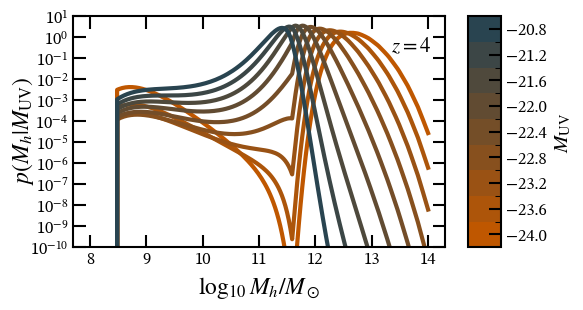

In [829]:
fig = PMh(best_fit, my_UVLF, np.arange(-24, -20.5, 0.4), [4])

In [ ]:
#fig.savefig('/Users/eb35267/Desktop/code/home/figures/PMh_z4.png', bbox_inches='tight')

# Push SFE as high as it can go

In [19]:
backend_file = '/Users/eb35267/Desktop/code/home/figures/remove_weibel_limit_z_fix_beta/zoom_in/samples.h5'

In [77]:
samples, best_fit, _, labels = my_UVLF.get_fit(backend_file)

In [230]:
def get_sigma_ellipse(samples, n_sigma):
    x,y = samples[:,0], samples[:,1]
    mean2d = [x.mean(), y.mean()]
    covariance = np.cov(x,y)

    # Get the length & direction of the axes of the ellipse describing the covariance between x & y
    length, dir_vec = np.linalg.eigh(C)
    # Get the index corresponding to the major axis (longer than the minor axis)
    maj_idx = np.argmax(length)
    maj_length, maj_vec = np.sqrt(length[maj_idx]), dir_vec[maj_idx] # sqrt(length) corresponds to 1 sigma from the mean
    maj_ax_endpoints = [mean2d - (n_sigma*maj_length*maj_vec), mean2d + (n_sigma*maj_length*maj_vec)]

    return maj_ax_endpoints
    
    

In [233]:
maj_ax_endpoints = get_sigma_ellipse(samples[:,4:6], n_sigma = 3)

In [234]:
maj_ax_endpoints

[array([-0.71398897,  0.02397716]), array([-1.15994919, -0.10750175])]

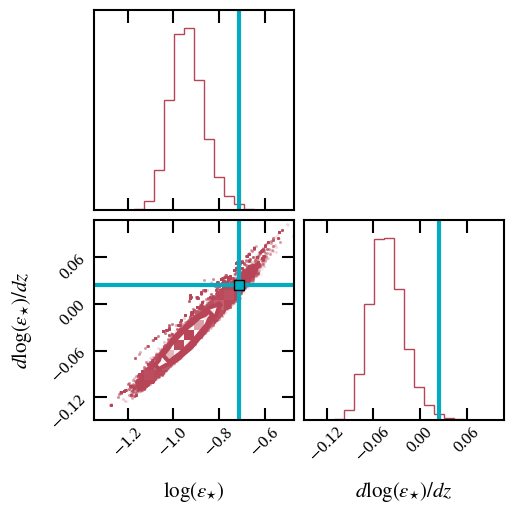

In [235]:
corner = eplots.make_corner(my_UVLF, backend_file = backend_file, excluded_params = ['dalphadz', 'logMc', 'dlogMcdz', 'sig', 'alpha', 'dsigdz', 'dsigdlogM']
                            ,true_vals = maj_ax_endpoints[0])

In [ ]:
#corner.savefig('/Users/eb35267/Desktop/code/home/figures/high_sfe_limit/best_fit.png', bbox_inches='tight')

In [236]:
test_fit = [0.87, 0.05, 11.71, 0, -0.71, 0.02, 0.17, 0.17, -0.86]

Text(0.5, 1.0, 'best fit')

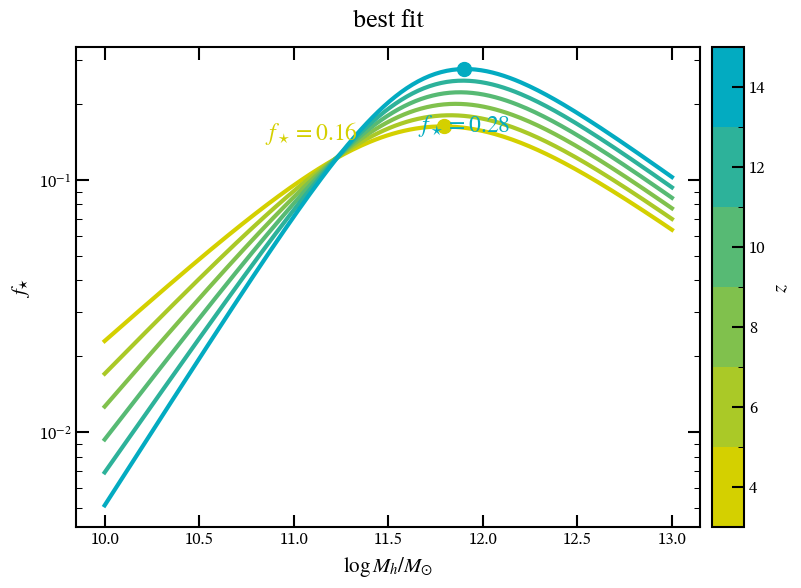

In [238]:
sfe_high, sfe_ax = eplots.sfe_shape_diff_z(my_UVLF, param_values = test_fit, zs = np.arange(4, 16, 2), id_max = True)
sfe_ax.set_title(r'best fit')

In [ ]:
#sfe_high.savefig('/Users/eb35267/Desktop/code/home/figures/high_sfe_limit/best_fit_sfe.png', bbox_inches='tight')

# Old stuff

In [89]:
param_data = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 
                                     'dbetadz': {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 
                                     'dlogMcdz':{'fit':False, 'value':0}})

In [144]:
my_UVLF = eMCMC.UVLF(sorted_data, param_data)

In [152]:
def sfe_shape_diff_fits(fits, fit_labels, my_UVLF, Mhtab):

    fig, ax = plt.subplots()
    
    for fit, fit_label in zip(fits, fit_labels):
        params = my_UVLF.time_evolution(fit, 0)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        SFEs = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, 0, 10**Mhtab)
        
        ax.plot(Mhtab, SFEs, label = fit_label)

    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
    ax.legend()
    ax.set_yscale('log')
        
        
    return fig

In [153]:
fit_456 = [0.71, -0.54, 11.79, -0.81, 0.07, -0.61]
fit_789 = [0.78, -0.54, 11.79, -0.99, 0.23, -0.61]
fit_10plus = [0.3, -0.54, 11.79, -3.09, 1.4, -0.52]

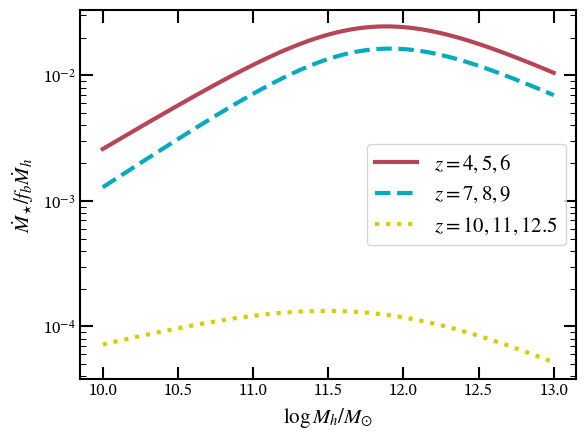

In [189]:
fig = sfe_shape_diff_fits([fit_456, fit_789, fit_10plus], [r'$z=4, 5, 6$', r'$z= 7, 8, 9$', r'$z=10, 11, 12.5$'],
                          my_UVLF, Mhtab = np.linspace(10, 13, 200))

In [190]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/sfe_comparison_narrowed_fixed.png', bbox_inches = 'tight')

In [213]:
def compare_MUV_distribution(my_UVLF, fits, fit_labels, Mhtab):
    fig, ax = plt.subplots()
    MUV_range = np.linspace(-15, -22, 500)
    ax.invert_xaxis()
    
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    dM = Mhtab[1]-Mhtab[0] # Separation between each halo mass
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+dM, dM), cmap.N)
    
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab 
    
    for fit, fit_label, ls in zip(fits, fit_labels, ['-', (0, (5, 1))]):
        #total_prob = np.zeros_like(MUV_range)
        params = my_UVLF.time_evolution(fit, 0)
        astroparams = my_UVLF.param_wrapper(params)
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, 10**Mhtab, 0, 0)
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV)
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX)

        ax.plot(MUV_range[0], 0, ls = ls, color = 'black', label = fit_label) # Make invisible line for the legend purposes


        for sigUV, MUV_bar, Mh in zip(params[-1], MUVbarlist, Mhtab):
            frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
            color = cmap(frac)
            #prob = gaussian(MUV_range, sigUV, MUV_bar)
            #total_prob += prob
            ax.plot(MUV_range, gaussian(MUV_range, sigUV, MUV_bar), color = color, ls = ls)

        #plt.plot(MUV_range, total_prob, color = 'black', ls = ls)
        

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-(dM/2), Mhtab.max()+(1.5*dM), dM) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$')

    ax.set_ylabel(r'$p(M_{\rm{UV}}|M_h)$')
    ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    ax.legend()
    ax.set_yscale('log')
    ax.set_ylim(1e-20, 10)
    

    return fig

In [7]:
fig = compare_MUV_distribution(my_UVLF, [fit_456, fit_10plus], [r'$z=4, 5, 6$', r'$z=10, 11, 12.5$'], 
                               Mhtab = np.arange(7, 9, 0.5))

NameError: name 'compare_MUV_distribution' is not defined

In [215]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/MUV_comparison_narrowed_fixed.png')

In [38]:
from astropy import constants as c

In [53]:
(2.5*np.log10(25))-2.5

0.9948500216800942

In [57]:
(1.43e26)**(1/4)

3458071.8244567155

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


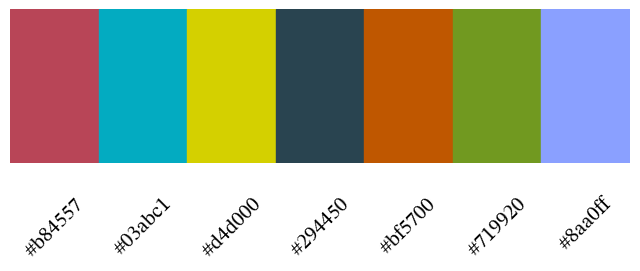

In [60]:
eplots.plot_colors()

In [8]:
np.sqrt(6.67e-20*4e30/(0.39*1.496e8))

67.62305895395347

In [14]:
def make_prediction(my_UVLF, z_plot, comparison_fits = [], comparison_labels = [], 
                      ncols = 3, title = 'UVLF prediction'):
    
    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    
    # Adjust size & spacing
    fig.set_size_inches(3*ncols, 3*math.ceil((nz+1)/ncols))
    plt.subplots_adjust(wspace = 0, hspace = 0.3)

    # Set the same y limits for all the plots
    ylo, yhi = np.log10(min([min(dat[3]) for dat in my_UVLF.data]))-0.25, np.log10(max([max(dat[3]) for dat in my_UVLF.data]))+0.25 

    # Get the x grid to evaluate the UVLF over
    plot_xdat, plot_xerr = my_UVLF.data[0][2], my_UVLF.data[0][5] # Use the lowest redshift MUV centers & bins as the grid to calculate the
                                                                # theoretical UVLF on
    i = 0 # Can't use enumerate because we're allowing for the possibility that the user will want to skip certain z bins 
    zerr = 0.5
    for zdat in z_plot: 
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])

        # Plot comparison fits
        for fit, label, color, ls in zip(comparison_fits, comparison_labels, [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green], 
                                        ['solid', 'dashdot', 'dashed', 'dotted']):
            ax.plot(plot_xdat, np.log10(my_UVLF.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr, fit)), color = color, 
                       label = fr'{label}', linestyle = ls, zorder = 1)

        ax.invert_xaxis()
        ax.set_ylim(ylo, yhi)
        ax.set_xlim(np.max(plot_xdat)+0.25, np.min(plot_xdat)-0.25)
        ax.set_title(fr'$z \simeq {round(zdat, 1)}$', fontsize = 16, pad = 8)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                       # axis labels
        if i%ncols != 0:
            ax.axes.yaxis.set_ticklabels([])

        i += 1


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'
    if math.ceil((nz+1)/ncols) > 1: # This means that there's more than one row of plots
        if i%ncols==0:
            fig.text(0.065, 0.5, ylabel, rotation = 'vertical')
            fig.text(0.5, 0.27, xlabel, ha = 'center')
        elif i%ncols == 1:
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = 0.07)
        else:
            fig.supylabel(ylabel, x = 0.05)
            fig.supxlabel(xlabel, y = 0)
        fig.text(.5, 0.95, title, ha = 'center', fontsize = 20)
    else:
        if nz == 1:
            ax.set_ylabel(ylabel)
            ax.set_xlabel(xlabel)
            ax.set_title(title)
        else:
            fig.text(0.065, 0.225, ylabel, rotation = 'vertical')
            fig.text(0.375, 0, xlabel, ha = 'center')
            fig.text(0.375, 1, title, ha = 'center', fontsize = 20)

    # Put legend outside the last axis
    handles, labels = ax.get_legend_handles_labels() # Grab handles/labels from the real axes
    fig_ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
    fig_ax.axis("off")  
    fig_ax.legend(handles, labels, loc='center left')
    
    return fig


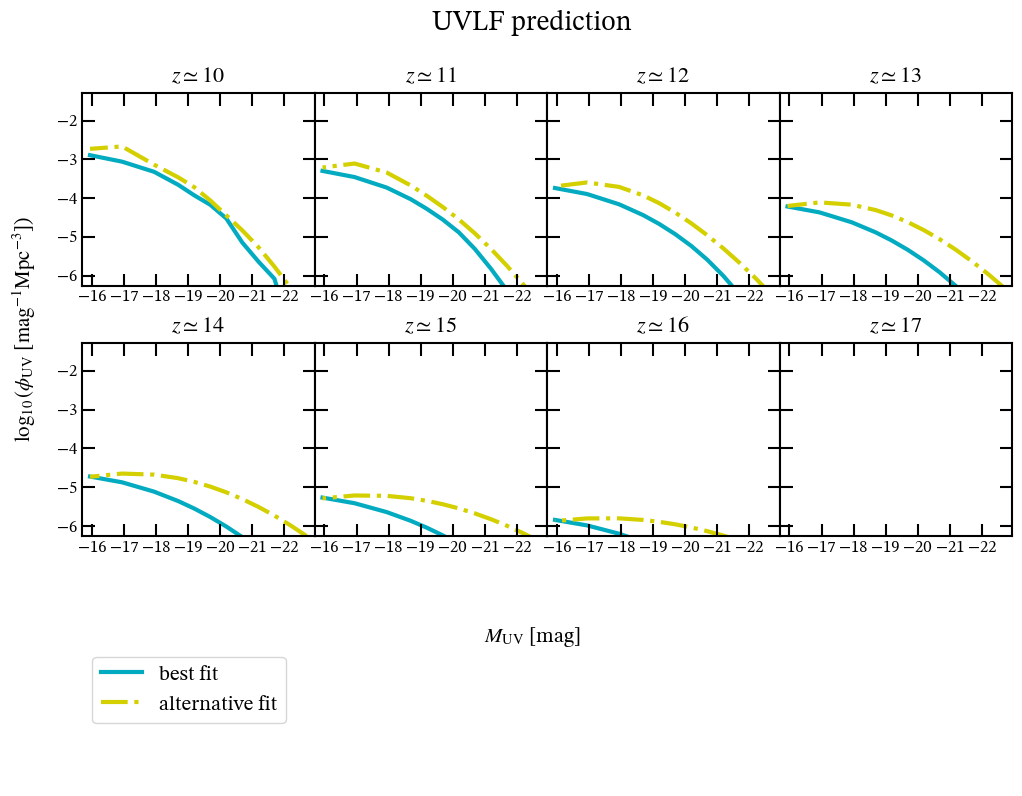

In [15]:
z_plot = np.arange(10, 18, 1)
fig = make_prediction(my_UVLF, z_plot, comparison_fits = [best_fit, other_fit], 
                               comparison_labels = [r'best fit', 'alternative fit'], ncols = 4)